In [2]:
#imports
import ipywidgets as widgets
from IPython.display import display, clear_output
import csv
from pathlib import Path
import importlib
import utils
importlib.reload(utils)
from utils import *

In [3]:
traits = [
    "adventerous","challenging","dark","emotional","funny","hopeful",
    "informative","inspiring","lighthearted","mysterious","reflective",
    "relaxing","sad","tense"
]

trait_sliders = {
    t: widgets.FloatSlider(
        value=0.0,
        min=0.0,
        max=100.0,             # changed: 0–100 scale
        step=1.0,              # whole-number steps
        description=t,
        continuous_update=True,
        readout_format=".0f",  # show integers
        layout=widgets.Layout(width="320px")
    )
    for t in traits
}

grid = widgets.GridBox(
    children=list(trait_sliders.values()),
    layout=widgets.Layout(
        grid_template_columns="repeat(2, 340px)",
        grid_gap="4px 12px"
    )
)

author_input = widgets.Text(
    value="none",
    description="Author",
    placeholder="Enter author name",
    layout=widgets.Layout(width="320px")
)

btn_author_none = widgets.Button(description="None", tooltip="Clear author filter")

btn_short  = widgets.Button(description="Short",  button_style="success")
btn_medium = widgets.Button(description="Medium", button_style="info")
btn_long   = widgets.Button(description="Long",   button_style="warning")

# Clear borders initially
for b in (btn_short, btn_medium, btn_long):
    b.layout.border = 'none'

output_area = widgets.Output()

selected_length = widgets.Text(
    value="short",
    description="Chosen",
    disabled=True,
    layout=widgets.Layout(width="200px")
)

book_label = widgets.HTML("<b> Select a book preset to autofill preferences</b>")
author_label = widgets.HTML("<b> Select preferred author</b>")
length_label = widgets.HTML("<b> Select preferred length</b>")
mood_label = widgets.HTML("<b> Select preferred moods</b>")
pace_label = widgets.HTML("<b> Select preferred pace</b>")

btn_pace_fast   = widgets.Button(description="Fast",   button_style="success")
btn_pace_medium = widgets.Button(description="Medium", button_style="info")
btn_pace_slow   = widgets.Button(description="Slow",   button_style="warning")

selected_pace = widgets.Text(
    value="fast",
    description="Pace",
    disabled=True,
    layout=widgets.Layout(width="200px")
)

def set_length(choice):
    selected_length.value = choice
    for b in (btn_short, btn_medium, btn_long):
        b.layout.border = 'none'
    # Add border to selected
    if choice == "short":
        btn_short.layout.border = "3px solid #2e7d32"   # green
    elif choice == "medium":
        btn_medium.layout.border = "3px solid #0288d1"  # blue
    elif choice == "long":
        btn_long.layout.border = "3px solid #f57c00"    # orange

def clear_author(_):
    author_input.value = "none"

def set_pace(choice):
    selected_pace.value = choice
    for b in (btn_pace_fast, btn_pace_medium, btn_pace_slow):
        b.layout.border = 'none'
    # Add border to selected
    if choice == "fast":
        btn_pace_fast.layout.border = "3px solid #2e7d32"   # green
    elif choice == "medium":
        btn_pace_medium.layout.border = "3px solid #0288d1"  # blue
    elif choice == "slow":
        btn_pace_slow.layout.border = "3px solid #f57c00"    # orange

btn_author_none.on_click(clear_author)
btn_short.on_click(lambda _: set_length("short"))
btn_medium.on_click(lambda _: set_length("medium"))
btn_long.on_click(lambda _: set_length("long"))

btn_pace_fast.on_click(lambda _: set_pace("fast"))
btn_pace_medium.on_click(lambda _: set_pace("medium"))
btn_pace_slow.on_click(lambda _: set_pace("slow"))


BOOK_CSV_PATH = Path("book_list.csv")

def classify_length_from_pages(pages: int) -> str:
    if pages <= 250:
        return "short"
    if pages <= 500:
        return "medium"
    return "long"

trait_keys = [
    "adventerous","challenging","dark","emotional","funny","hopeful",
    "informative","inspiring","lighthearted","mysterious","reflective",
    "relaxing","sad","tense"
]

def load_book_rows(path: Path):
    if not path.exists():
        return []
    rows = []
    with path.open(newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for r in reader:
            rows.append({k.lower().strip(): v for k, v in r.items()})
    return rows

CHOSEN_TITLES = [
    "The Name of the Wind",
    "The Hobbit",
    "The Night Circus",
    "Words of Radiance",
    "Furies of Calderon",
    "Mort",
    "The Spellshop",
    "Red Sister",
    "Babel",
    "Magician",
]

all_rows = load_book_rows(BOOK_CSV_PATH)

def select_rows_by_titles(rows, wanted_titles):
    if not wanted_titles:
        return rows[:10]

    by_title = { (r.get("title","").strip().lower()): r for r in rows }
    selected = []
    missing = []
    for t in wanted_titles[:10]:
        key = t.strip().lower()
        r = by_title.get(key)
        if r:
            selected.append(r)
        else:
            missing.append(t)
    if missing and output_area:
        with output_area:
            print("Warning - titles not found in CSV:", ", ".join(missing))
    return selected

raw_books = select_rows_by_titles(all_rows, CHOSEN_TITLES)

book_buttons = []
book_presets = []

for r in raw_books:
    title = r.get("title", "").strip()
    if not title:
        continue
    author_val = r.get("author", "").strip()
    length_field = r.get("length", "").strip()
    length_cat = ""
    if length_field.isdigit():
        length_cat = classify_length_from_pages(int(length_field))
    else:
        lf = length_field.lower()
        if lf in ("short","medium","long"):
            length_cat = lf
        else:
            length_cat = "medium"  # fallback
    pace_val = r.get("pace", "").strip().lower()
    if pace_val not in ("fast","medium","slow"):
        pace_val = "medium"

    mood_values = []
    for mk in trait_keys:
        raw_val = r.get(mk, "").strip()
        try:
            mv = float(raw_val)
        except:
            mv = 0.0
        if mv < 0: mv = 0.0
        if mv > 100: mv = 100.0
        mood_values.append(mv)

    book_presets.append({
        "title": title,
        "author": author_val,
        "length": length_cat,
        "pace": pace_val,
        "moods": {k: v for k, v in zip(trait_keys, mood_values)}
    })

# Create buttons (show title, truncate if long)
for bp in book_presets:
    label = bp["title"][:24] + ("…" if len(bp["title"]) > 24 else "")
    b = widgets.Button(description=label, layout=widgets.Layout(width="180px"))
    book_buttons.append(b)

books_box = widgets.HBox(book_buttons, layout=widgets.Layout(flex_flow="row wrap"))

def apply_book_preset(preset):
    set_length(preset["length"])
    set_pace(preset["pace"])
    for mk, val in preset["moods"].items():
        trait_sliders[mk].value = val

for btn, preset in zip(book_buttons, book_presets):
    btn.on_click(lambda _, p=preset: apply_book_preset(p))


ui = widgets.VBox([
    book_label,
    books_box,
    author_label,
    widgets.HBox([author_input, btn_author_none]),
    length_label,
    widgets.HBox([btn_short, btn_medium, btn_long]),
    selected_length,
    pace_label,
    widgets.HBox([btn_pace_fast, btn_pace_medium, btn_pace_slow]),
    selected_pace,
    mood_label,
    grid,
    output_area
])

display(ui)

def get_current_preferences():
    # Return: [title(always "none"), author, length, [mood values 0–100], pace]
    title = "none"
    author = ((author_input.value or "").strip() or "none")
    length = selected_length.value.strip()
    mood_values = [int(trait_sliders[t].value) for t in traits]  # now 0–100
    pace = selected_pace.value.strip()
    return [title, author, length, mood_values, pace]

def on_any_change(change):
    if change["name"] == "value":
        pass

for s in trait_sliders.values():
    s.observe(on_any_change)

In [4]:
df_raw, normalized_df, scaler, _ = load_input("./book_list.csv", adventurous_weight=0)
centers, memberships, fpc = build_fuzzy_model(normalized_df, n_clusters=4)
print("FPC=", fpc)

FPC= 0.6099233740697063


In [5]:
# input fuzzy variables
book_len = ctrl.Antecedent(np.arange(0,3,1), "book_len")
book_pace = ctrl.Antecedent(np.arange(0,3,1), "book_pace")

# output fuzzy variable
preference = ctrl.Consequent(np.arange(0,11,1), "preference")

# membership functions
book_len["short"] = fuzz.trimf(book_len.universe, [0,0,1])
book_len["medium"] = fuzz.trimf(book_len.universe, [0,1,2])
book_len["long"] = fuzz.trimf(book_len.universe, [1,2,2])

book_pace["slow"] = fuzz.trimf(book_pace.universe, [0,0,1])
book_pace["medium"] = fuzz.trimf(book_pace.universe, [0,1,2])
book_pace["fast"] = fuzz.trimf(book_pace.universe, [1,2,2])

preference["low"] = fuzz.trimf(preference.universe, [0,0,5])
preference["medium"] = fuzz.trimf(preference.universe, [0,5,10])
preference["high"] = fuzz.trimf(preference.universe, [5,10,10])


In [6]:
# fuzzy rules
rule1 = ctrl.Rule(book_len["short"] & book_pace["fast"], preference["high"])
rule2 = ctrl.Rule(book_len["short"] & book_pace["medium"], preference["medium"])
rule3 = ctrl.Rule(book_len["short"] & book_pace["slow"], preference["low"])

rule4 = ctrl.Rule(book_len["medium"] & book_pace["fast"], preference["medium"])
rule5 = ctrl.Rule(book_len["medium"] & book_pace["medium"], preference["high"])
rule6 = ctrl.Rule(book_len["medium"] & book_pace["slow"], preference["medium"])

rule7 = ctrl.Rule(book_len["long"] & book_pace["fast"], preference["low"])
rule8 = ctrl.Rule(book_len["long"] & book_pace["medium"], preference["medium"])
rule9 = ctrl.Rule(book_len["long"] & book_pace["slow"], preference["high"])

In [7]:
# controller
book_pref_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3,
    rule4, rule5, rule6,
    rule7, rule8, rule9
])

book_pref_sim = ctrl.ControlSystemSimulation(book_pref_ctrl)

Best Number cluster (fpc) =  40
Best Number cluster (silouhette) =  20


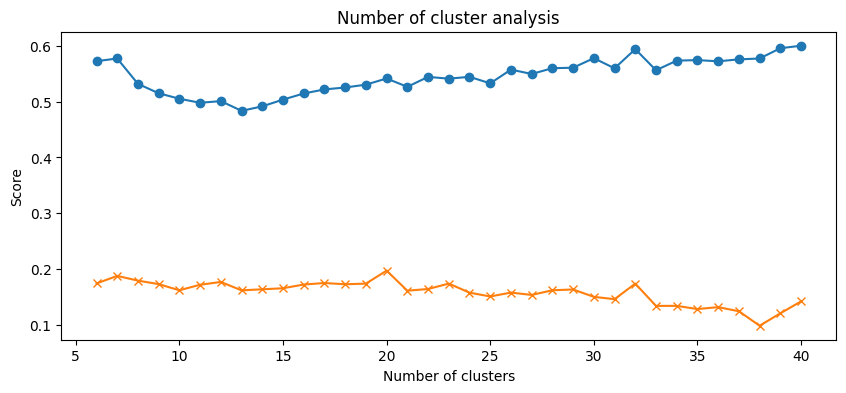

In [8]:
df_raw, normalized_df, scaler, feat_names = load_input("./book_list.csv", adventurous_weight=0)
best_k = evaluate_fpc(normalized_df, k_min=6, k_max=40)

In [15]:
centers,memberships, fpc = build_fuzzy_model(normalized_df,20)
print("FPC=", fpc)

FPC= 0.5303656140166835


In [16]:
visualize_clusters(normalized_df,memberships,best_k,df_raw)

c:\Users\hansa\Documents\Fuzzysets\fuzzy\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Cluster 0 top features: ['emotional', 'mysterious', 'reflective', 'hopeful', 'inspiring']
Cluster 1 top features: ['funny', 'lighthearted', 'mysterious', 'hopeful', 'emotional']
Cluster 2 top features: ['mysterious', 'emotional', 'tense', 'dark', 'hopeful']
Cluster 3 top features: ['lighthearted', 'hopeful', 'funny', 'emotional', 'inspiring']
Cluster 4 top features: ['dark', 'mysterious', 'tense', 'emotional', 'challenging']
Cluster 5 top features: ['dark', 'tense', 'emotional', 'mysterious', 'challenging']
Cluster 6 top features: ['emotional', 'dark', 'tense', 'challenging', 'reflective']


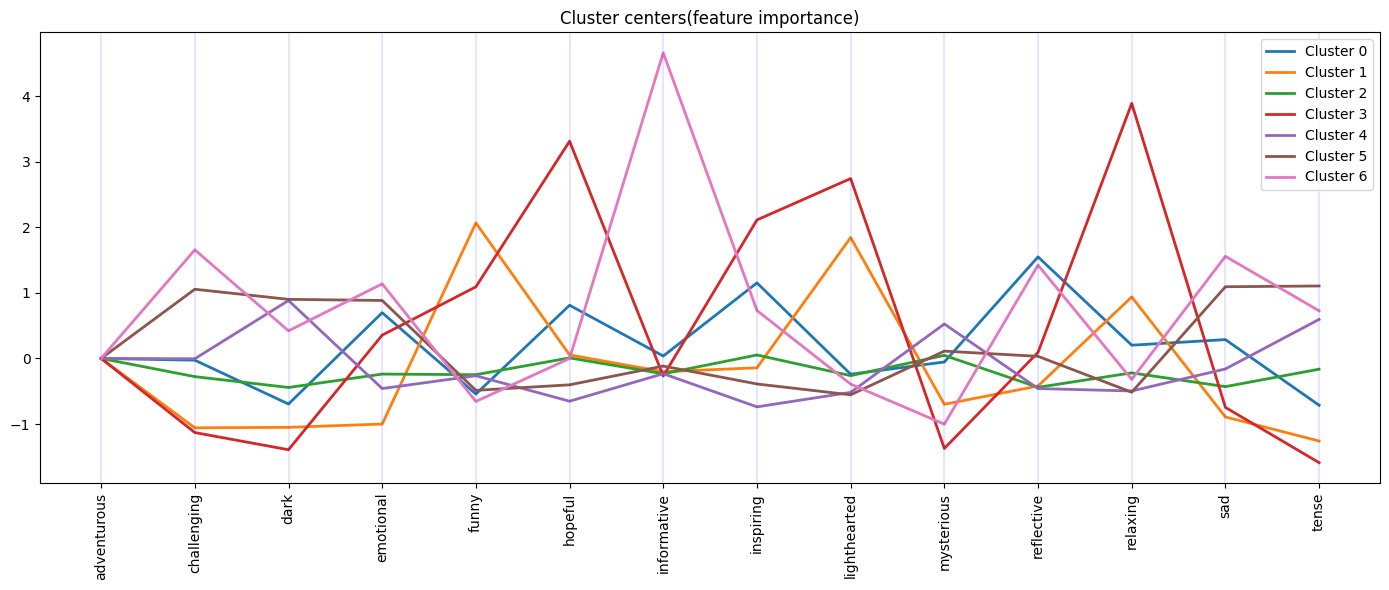

In [11]:
plot_cluster_centers(centers,feat_names, scaler, top_n =5)

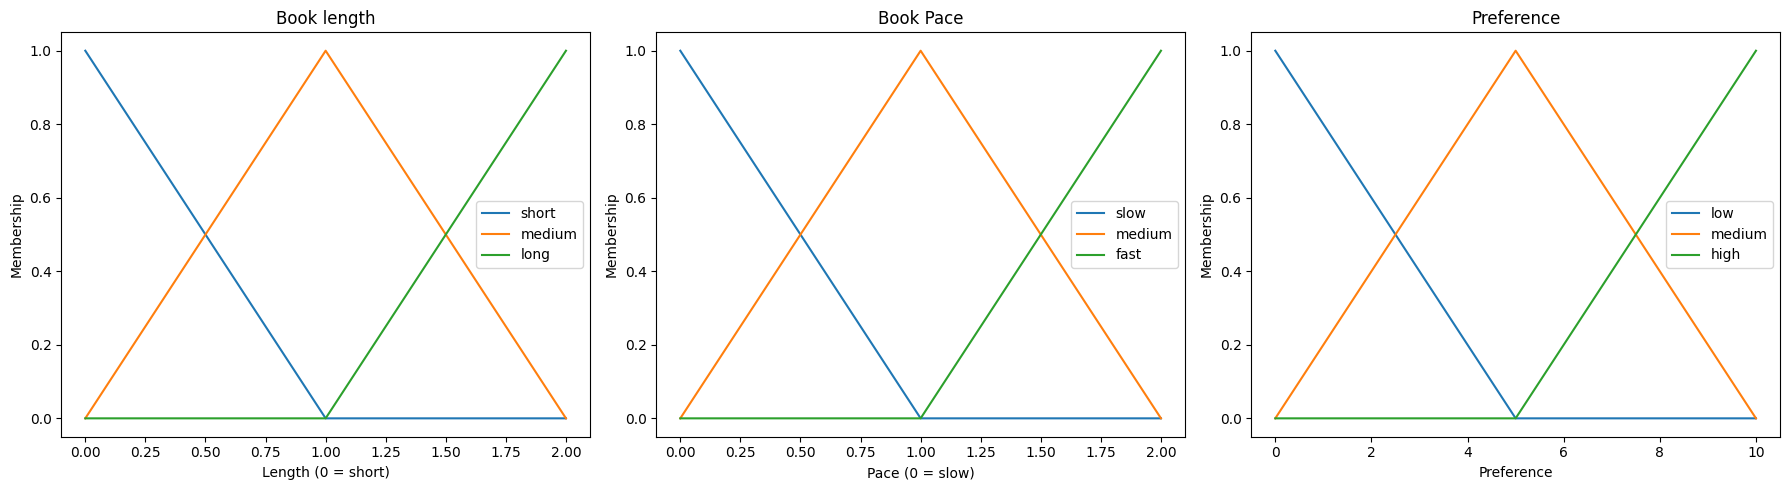

In [12]:
# book preferences system
fig, axes = plt.subplots(1,3, figsize=(18,5))
for label, mf in book_len.terms.items():
    axes[0].plot(book_len.universe, mf.mf, label=label)
axes[0].set_title("Book length")
axes[0].set_xlabel("Length (0 = short)")
axes[0].set_ylabel("Membership")
axes[0].legend()
for label, mf in book_pace.terms.items():
    axes[1].plot(book_pace.universe, mf.mf, label=label)
axes[1].set_title("Book Pace")
axes[1].set_xlabel("Pace (0 = slow)")
axes[1].set_ylabel("Membership")
axes[1].legend()
for label, mf in preference.terms.items():
    axes[2].plot(preference.universe, mf.mf, label=label)
axes[2].set_title("Preference")
axes[2].set_xlabel("Preference")
axes[2].set_ylabel("Membership")
axes[2].legend()

plt.tight_layout()
plt.show()


In [13]:
user = get_current_preferences()
print("User preferences:", user)
user_len = user[2]
user_pace = user[4]
fv = encode_user_input(user, feat_names, adventurous_weight=0)
fv_scaled = scale_user_input(fv,scaler, feat_names)
print("User feature vector (scaled):", fv_scaled)
cluster_index, u = predict_cluster(fv_scaled, centers)
print("User belongs to cluster:", cluster_index)
recommendations = recommend_books(df_raw, memberships, cluster_index, book_pref_ctrl, top_k=10, user_len=user_len, user_pace=user_pace, cluster_weight=0.7, rule_weight=0.1, use_rules = True)
recommendations

User preferences: ['none', 'none', 'short', [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'fast']
User feature vector (scaled): [[ 0.         -1.38460425 -1.44819293 -1.81990097 -0.90164794 -1.09192866
  -0.38177834 -1.16169004 -0.62508785 -1.96148139 -1.01279529 -0.57118719
  -1.04326275 -1.73572562]]
User belongs to cluster: 2


,title,author,length,adventurous,challenging,dark,emotional,funny,hopeful,informative,...,tense,paceslow,pacemedium,pacefast,rating,fuzzy_pace,fuzzy_len,cluster_strenght,fuzzy_preference,final_score
37,Magician,Raymond E. Feist,681,98,18,21,26,14,18,1,...,30,11,55,33,4.10,medium,long,0.989510,5.000000,0.742657
59,Green Rider,Kristen Britain,471,98,9,18,17,5,18,0,...,30,20,68,11,3.98,medium,medium,0.921969,8.333333,0.728711
20,Spinning Silver,Naomi Novik,480,88,11,38,38,3,23,0,...,27,9,62,27,4.17,medium,medium,0.915379,8.333333,0.724098
87,Graceling,Kristin Cashore,471,98,11,15,43,16,21,0,...,29,25,63,10,4.01,medium,medium,0.910887,8.333333,0.720954
85,Eragon,Christopher Paolini,503,99,12,13,29,9,18,0,...,26,16,63,20,3.75,medium,long,0.950814,5.000000,0.715570
58,Sorcery of Thorns,Margaret Rogerson,456,95,10,25,38,35,19,0,...,24,25,67,7,4.05,medium,medium,0.815571,8.333333,0.654233
36,Furies of Calderon,Jim Butcher,688,98,12,29,23,11,15,1,...,42,28,62,9,4.24,medium,long,0.852626,5.000000,0.646838
82,Dragonflight,Anne McCaffrey,320,98,9,4,12,7,15,1,...,17,29,55,14,3.76,medium,medium,0.782468,8.333333,0.631061
9,Uprooted,Naomi Novik,435,92,10,49,33,8,20,0,...,31,16,63,19,4.01,medium,medium,0.767646,8.333333,0.620685
32,The Name of the Wind,Patrick Rothfuss,661,97,15,34,33,24,9,0,...,24,9,55,34,4.54,medium,long,0.801016,5.000000,0.610711


In [14]:
recs_without_rules = recommend_books(df_raw, memberships, cluster_index, book_pref_ctrl, top_k=10, user_len=user_len, user_pace=user_pace, cluster_weight=0.7, rule_weight=0.3, use_rules = False)
recs_without_rules

,title,author,length,adventurous,challenging,dark,emotional,funny,hopeful,informative,...,relaxing,sad,tense,paceslow,pacemedium,pacefast,rating,fuzzy_pace,fuzzy_len,cluster_strenght
37,Magician,Raymond E. Feist,681,98,18,21,26,14,18,1,...,4,8,30,11,55,33,4.10,medium,long,0.989510
85,Eragon,Christopher Paolini,503,99,12,13,29,9,18,0,...,3,7,26,16,63,20,3.75,medium,long,0.950814
59,Green Rider,Kristen Britain,471,98,9,18,17,5,18,0,...,1,2,30,20,68,11,3.98,medium,medium,0.921969
20,Spinning Silver,Naomi Novik,480,88,11,38,38,3,23,0,...,2,6,27,9,62,27,4.17,medium,medium,0.915379
87,Graceling,Kristin Cashore,471,98,11,15,43,16,21,0,...,2,6,29,25,63,10,4.01,medium,medium,0.910887
36,Furies of Calderon,Jim Butcher,688,98,12,29,23,11,15,1,...,1,3,42,28,62,9,4.24,medium,long,0.852626
58,Sorcery of Thorns,Margaret Rogerson,456,95,10,25,38,35,19,0,...,4,6,24,25,67,7,4.05,medium,medium,0.815571
32,The Name of the Wind,Patrick Rothfuss,661,97,15,34,33,24,9,0,...,3,12,24,9,55,34,4.54,medium,long,0.801016
82,Dragonflight,Anne McCaffrey,320,98,9,4,12,7,15,1,...,2,1,17,29,55,14,3.76,medium,medium,0.782468
9,Uprooted,Naomi Novik,435,92,10,49,33,8,20,0,...,2,7,31,16,63,19,4.01,medium,medium,0.767646
